In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error, precision_score, recall_score, f1_score, accuracy_score
from scipy.stats import norm
import wfdb
import pandas as pd
import time
import random
import json  # for storing arrays as strings
from scipy.stats import fisher_exact, mannwhitneyu
from sklearn.decomposition import PCA

# ============ REPRODUCIBLITY BLOCK ==============
seed = 46
random.seed(seed)
np.random.seed(seed)

# ====== LOAD REAL ECG ======
record = '106'
fs = 360  # Sampling frequency in Hz
data_folder = 'mitdb_data_full'
annotation_folder = 'mit-bih-arrhythmia-database-1.0.0'

NORMAL_BEATS = ['.', 'N', 'L', 'R', 'e', 'j']
ARRHYTHMIC_BEATS = ['A', 'a', 'J', 'S', 'V', 'E', 'F']

# ====== CONFIG ======
input_len = 10
pred_len = 1
steps = 1

# Epsilon values for entropy calculations
# eps_values = [0.9, 0.5, 0.1, 0.05, 1e-2, 1e-4, 1e-6, 1e-10] # Finer granularity
eps_values = [1e-6] # take lower value of epsilon where the topological entropy is already saturated for low no of reservoirs

# ====== Load annotations ======
record_path = os.path.join(annotation_folder, record)
ann = wfdb.rdann(record_path, extension='atr')

# ====== Load signal ======
signal_path = os.path.join(data_folder, f'{record}.npy')
signal = np.load(signal_path)[:, 0]  # Lead I only

# ====== Parameters ======
beat_length = 180  # samples before the beat

# ====== FUNCTION: Extract beat segments ======
def get_segments(signal, ann_samples, ann_symbols, beat_length, target_symbols):
    segments = []
    indices = []
    for s, sym in zip(ann_samples, ann_symbols):
        if sym in target_symbols and s >= beat_length:
            seg = signal[s - beat_length:s]
            segments.append(seg)
            indices.append(s)
    return segments, indices

# ====== Extract normal and arrhythmic beats ======
normal_segments, normal_indices = get_segments(signal, ann.sample, ann.symbol, beat_length, NORMAL_BEATS)
arr_segments, arr_indices = get_segments(signal, ann.sample, ann.symbol, beat_length, ARRHYTHMIC_BEATS)

# ---- Basic numbers ----
num_total_norm = len(normal_segments)
num_train_beats = 500
num_val_beats = 100

num_test_norm = 100
num_test_arr = 100

# ---- Random split for normal beats ----
all_norm_indices = np.arange(num_total_norm)

# Shuffle the indices to randomize selection
np.random.shuffle(all_norm_indices)

# Choose random validation indices *within* normal beats
val_indices = all_norm_indices[:num_val_beats]
train_indices = all_norm_indices[num_val_beats:num_val_beats + num_train_beats]
test_norm_indices = all_norm_indices[num_val_beats + num_train_beats:
                                     num_val_beats + num_train_beats + num_test_norm]

# ---- Create splits ----
train_segments = [normal_segments[i] for i in train_indices]
val_segments = [normal_segments[i] for i in val_indices]
test_segments = [normal_segments[i] for i in test_norm_indices] + arr_segments[:num_test_arr]

print(f"Train: {len(train_segments)} normal beats")
print(f"Validation: {len(val_segments)} normal beats (random from training pool)")
print(f"Test: {len(test_segments)} beats ({len(test_norm_indices)} normal + {num_test_arr} arrhythmic)")

# ====== Convert to numpy arrays ======
train_segments = np.array(train_segments)
val_segments = np.array(val_segments)
test_segments = np.array(test_segments)

print(f"\nShapes:")
print(f"  Train: {train_segments.shape}")
print(f"  Validation: {val_segments.shape}")
print(f"  Test: {test_segments.shape}")


Train: 500 normal beats
Validation: 100 normal beats (random from training pool)
Test: 200 beats (100 normal + 100 arrhythmic)

Shapes:
  Train: (500, 180)
  Validation: (100, 180)
  Test: (200, 180)


In [2]:
# ====== Generate parameter distribution that spans stable → chaotic ======

max_N = 200  # total reservoirs
tau_range = (0.8, 2.0)

# Define the extreme ends
stable_range = [(0.02, 0.07),  (0.02, 0.07),  (6.0, 7.0)]
chaotic_range = [(0.18, 0.22), (0.18, 0.22), (5.5, 5.9)]

# ====== Create hybrid parameter ranges ======
# For example, interpolate 30% stable → 70% chaotic
mix_ratio = 1   # 0 = purely stable, 1 = purely chaotic

hybrid_range = []
for (s_low, s_high), (c_low, c_high) in zip(stable_range, chaotic_range):
    low  = s_low  + mix_ratio * (c_low  - s_low)
    high = s_high + mix_ratio * (c_high - s_high)
    hybrid_range.append((low, high))

print("Hybrid parameter range:", hybrid_range)

# ====== Generate parameters from this blended range ======
params_fixed = np.array([
    [np.random.uniform(*r) for r in hybrid_range] + [np.random.uniform(*tau_range)]
    for _ in range(max_N)
])

print(f"Generated {max_N} hybrid reservoirs between stable and chaotic regimes.")
print("Example parameters:\n", params_fixed[:5])


Hybrid parameter range: [(0.18, 0.22), (0.18, 0.22), (5.5, 5.9)]
Generated 200 hybrid reservoirs between stable and chaotic regimes.
Example parameters:
 [[0.18852575 0.21459112 5.75340433 1.00128084]
 [0.21028851 0.18396638 5.77408947 1.26749928]
 [0.1869403  0.21159601 5.74263341 1.20060536]
 [0.21917282 0.2100114  5.63370393 1.95216037]
 [0.21297011 0.21303108 5.52218663 0.951526  ]]


In [3]:
# ====== BEAT-BASED DATA PREP (no continuous time) ======
def sliding_data(segment, input_len, pred_len):
    """
    Generate input-output pairs (X, Y) for one 1D segment.
    Returns:
        X_y : (input_len x num_windows)
        Y   : (pred_len x num_windows)
    """
    X_y, Y = [], []
    for t_idx in range(len(segment) - input_len - pred_len + 1):
        X_y.append(segment[t_idx : t_idx + input_len])
        Y.append(segment[t_idx + input_len : t_idx + input_len + pred_len])
    return np.array(X_y).T, np.array(Y).T


# ====== DSRN SYSTEM ======
def rossler_system(t, X, params, N):
    X = X.reshape(N, 3)
    dxdt = (1 / params[:, 3]) * (-X[:, 1] - X[:, 2])
    dydt = (1 / params[:, 3]) * (X[:, 0] + params[:, 0] * X[:, 1])
    dzdt = (1 / params[:, 3]) * (params[:, 1] + X[:, 2] * (X[:, 0] - params[:, 2]))
    return np.stack([dxdt, dydt, dzdt], axis=1).flatten()

# ============ COMPUTE ENTROPY ==============
def compute_topological_entropy(trajectory, eps_values):
    entropy_estimates = {}
    for eps in eps_values:
        unique_orbits = set()
        for point in trajectory:
            rounded_point = tuple(np.round(point / eps))  
            unique_orbits.add(rounded_point)
        N_n_eps = len(unique_orbits)
        entropy_estimates[eps] = np.log(N_n_eps) / len(trajectory)  
    return entropy_estimates

# ====== Modified compute_phi to accept fixed params ======
def compute_phi(X_norm, N, steps, R=None, params=None):
    M, D = X_norm.shape

    # Use fixed params if passed, otherwise generate new ones
    if params is None:
        raise ValueError("Please pass fixed params for reproducible experiments")

    params_used = params[:N]  # take only the first N reservoirs

    # Compute mean and std per parameter
    param_means = np.mean(params_used, axis=0)  # shape: (4,)
    param_stds  = np.std(params_used, axis=0)   # shape: (4,)

    if R is None:
        R = np.random.uniform(-1, 1, size=(3 * N, M))

    phi = np.zeros((3 * N, D))
    entropy_all = []

    for i in range(D):
        u = R @ X_norm[:, i]
        # t_eval = np.linspace(0, 100, 1000 * steps)
        t_eval = np.linspace(0, 20, 100 * steps)
        sol = solve_ivp(rossler_system, [t_eval[0], t_eval[-1]], u,
                        t_eval=t_eval, args=(params_used, N), rtol=1e-6, atol=1e-9)
        phi[:, i] = sol.y[:, -1]

        trajectory = sol.y.T
        trajectory = (trajectory - trajectory.mean(axis=0)) / trajectory.std(axis=0)
        entropy_values = compute_topological_entropy(trajectory, eps_values)
        entropy_all.append(np.mean(list(entropy_values.values())))

    mean_entropy = np.mean(entropy_all)
    
    # Return phi, R, params used, mean entropy, and param statistics
    return phi, R, params_used, mean_entropy, param_means, param_stds

# ====== Train DSRN with fixed parameter distribution ======
def train_dsrn(X_norm, Y_norm, N, steps, params_fixed):
    # Pass fixed params to compute_phi
    phi, R, params_used, _, param_means, param_stds = compute_phi(X_norm, N, steps, params=params_fixed)
    
    # Compute linear mapping S
    S, _, _, _ = np.linalg.lstsq(phi.T, Y_norm.T, rcond=None)
    
    return S.T, R, params_used, param_means, param_stds


# ====== Predict DSRN with fixed parameter distribution ======
def predict_dsrn(X_norm, S, R, params_fixed, N, steps):
    # Use the same fixed params
    phi, _, _, entropy_values, _, _ = compute_phi(X_norm, N, steps, R=R, params=params_fixed)
    return S @ phi, entropy_values

# Convert numpy arrays inside online_results so they become JSON-serializable
def convert_numpy(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, (np.float32, np.float64)):
        return float(obj)
    if isinstance(obj, (np.int32, np.int64)):
        return int(obj)
    if isinstance(obj, dict):
        return {k: convert_numpy(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [convert_numpy(v) for v in obj]
    return obj
    

In [4]:
# ====== CONCATENATE ALL SEGMENTS FOR TRAINING SINGLE S (NO TIME) ======
all_X_y_raw = []
all_Y_raw = []

for seg_idx, seg in enumerate(train_segments):
    if len(seg) < input_len + pred_len:
        print(f"Skipping segment {seg_idx}, too short for sliding window")
        continue

    # ====== SLIDING WINDOW ======
    X_y_raw, Y_raw = sliding_data(seg, input_len, pred_len)

    if X_y_raw.size == 0 or Y_raw.size == 0:
        print(f"Skipping segment {seg_idx}, sliding window returned empty arrays")
        continue

    # Collect raw (unscaled) data for global normalization later
    all_X_y_raw.append(X_y_raw)
    all_Y_raw.append(Y_raw)

# ====== CONCATENATE RAW WINDOWS ACROSS ALL SEGMENTS ======
X_y_all_raw = np.hstack(all_X_y_raw)  # (input_len, total_samples)
Y_all_raw   = np.hstack(all_Y_raw)    # (pred_len, total_samples)

print(f"Raw training shapes: X_y_all_raw={X_y_all_raw.shape}, Y_all_raw={Y_all_raw.shape}")


# PCA-transform the input windows
pca_train = PCA(n_components=3)
X_y_all_pca = pca_train.fit_transform(X_y_all_raw.T)   # shape: (samples, 3) 3 for 3 components

# DSRN requires (features × samples)
X_y_all_norm = X_y_all_pca.T    # shape: (3, samples)

# Output remains ECG windows
Y_all_norm = Y_all_raw      # shape: (samples, pred_len)

print(f"PCA training data shapes: X_y_all_norm = {X_y_all_norm.shape}, Output data shape (Y_all_norm) = {Y_all_norm.shape}")


Raw training shapes: X_y_all_raw=(10, 85000), Y_all_raw=(1, 85000)
PCA training data shapes: X_y_all_norm = (3, 85000), Output data shape (Y_all_norm) = (1, 85000)


In [5]:
N = 10
print(f"Running experiment for N = {N}")

# ====== TRAIN SINGLE DSRN ======
S, R, params, param_means, param_stds = train_dsrn(X_y_all_norm, Y_all_norm, N, steps, params_fixed)
print(f"Training done for N = {N}.")

Running experiment for N = 10
Training done for N = 10.


In [6]:
# ====== PREDICTION ON EACH SEGMENT (NO TIME) ======
all_predictions = []
all_true = []
all_entropy_values = []  # store average entropy from each segment

for seg_idx, seg in enumerate(train_segments):
    if len(seg) < input_len + pred_len:
        continue

    predictions = []
    segment_entropy_sum = 0.0
    segment_entropy_count = 0

    start = input_len
    while start + pred_len <= len(seg):
        # input = last `input_len` true values
        y_in = seg[start - input_len:start].reshape(-1, 1)

        # --- PCA transform the input window ---
        y_in_pca = pca_train.transform(y_in.T).T   # shape (3,1)


        # --- predict in raw scale ---
        y_pred_raw, entropy_values = predict_dsrn(
            y_in_pca, S, R, params, N, steps
        )
        
        # no inverse transform needed
        y_pred = y_pred_raw.flatten()

        predictions.extend(y_pred)

        # --- accumulate entropy ---
        if isinstance(entropy_values, dict):
            avg_entropy = np.mean(list(entropy_values.values()))
            segment_entropy_sum += avg_entropy
            segment_entropy_count += 1
        elif isinstance(entropy_values, (list, np.ndarray)):
            segment_entropy_sum += np.sum(entropy_values)
            segment_entropy_count += len(entropy_values)
        else:
            segment_entropy_sum += entropy_values
            segment_entropy_count += 1

        start += pred_len

    # ====== Average entropy for this segment ======
    if segment_entropy_count > 0:
        avg_entropy_seg = segment_entropy_sum / segment_entropy_count
        all_entropy_values.append(avg_entropy_seg)

    # ====== Align predictions with true values ======
    pred_seq = np.array(predictions[:len(seg) - input_len])
    true_seq = seg[input_len:input_len + len(pred_seq)]

    all_predictions.append(pred_seq)
    all_true.append(true_seq)

# ====== Compute overall average entropy ======
if all_entropy_values:
    overall_avg_entropy = np.mean(all_entropy_values)
    print(f"Overall Average Entropy across all segments: {overall_avg_entropy:.6f}")

save_overall_avg_entropy = overall_avg_entropy

r_values = []
mse_values = []
rmse_values = []

for pred_seq, true_seq in zip(all_predictions, all_true):
    # Do NOT slice true_seq again
    if len(true_seq) != len(pred_seq):
        continue  # skip if lengths mismatch

    # ---- Compute metrics ----
    if np.std(pred_seq) > 0 and np.std(true_seq) > 0:
        r = np.corrcoef(true_seq, pred_seq)[0, 1]        # Pearson correlation coefficient
        mse = mean_squared_error(true_seq, pred_seq)    # Mean squared error
        rmse = np.sqrt(mse)                              # Root mean squared error

        r_values.append(r)
        mse_values.append(mse)
        rmse_values.append(rmse)
    else:
        print("Skipping segment due to zero std (constant values)")

# ---- Average metrics ----
avg_r = np.mean(r_values)
avg_mse = np.mean(mse_values)
avg_rmse = np.mean(rmse_values)

Overall Average Entropy across all segments: 0.046052


In [7]:

# ====== VALIDATION PREDICTIONS (NO TIME) ======
val_predictions = []
val_true = []
val_entropy_values = []

for seg_idx, seg in enumerate(val_segments):
    if len(seg) < input_len + pred_len:
        continue

    predictions = []
    segment_entropy_sum = 0.0
    segment_entropy_count = 0

    start = input_len
    while start + pred_len <= len(seg):
        # ====== Input sequence ======
        y_in = seg[start - input_len:start].reshape(-1, 1)

        # --- PCA transform the input window ---
        y_in_pca = pca_train.transform(y_in.T).T   # shape (3,1)


        # --- predict in raw scale ---
        y_pred_raw, entropy_values = predict_dsrn(
            y_in_pca, S, R, params, N, steps
        )
        
        # no inverse transform needed
        y_pred = y_pred_raw.flatten()

        predictions.extend(y_pred)

        # ====== Accumulate entropy ======
        if isinstance(entropy_values, dict):
            avg_entropy = np.mean(list(entropy_values.values()))
            segment_entropy_sum += avg_entropy
            segment_entropy_count += 1
        elif isinstance(entropy_values, (list, np.ndarray)):
            segment_entropy_sum += np.sum(entropy_values)
            segment_entropy_count += len(entropy_values)
        else:
            segment_entropy_sum += entropy_values
            segment_entropy_count += 1

        start += pred_len

    # ====== Average entropy for this segment ======
    if segment_entropy_count > 0:
        avg_entropy_seg = segment_entropy_sum / segment_entropy_count
        val_entropy_values.append(avg_entropy_seg)

    # ====== Align predictions with true values ======
    pred_seq = np.array(predictions[:len(seg) - input_len])
    true_seq = seg[input_len:input_len + len(pred_seq)]

    val_predictions.append(pred_seq)
    val_true.append(true_seq)

# ====== Compute overall validation entropy ======
if val_entropy_values:
    overall_val_entropy = np.mean(val_entropy_values)
    print(f"Validation Average Topological Entropy: {overall_val_entropy:.6f}")
else:
    print("No entropy values computed for validation set.")

# ====== Compute metrics ======
r_values, mse_values, rmse_values = [], [], []
for pred_seq, true_seq in zip(val_predictions, val_true):
    if len(pred_seq) != len(true_seq):
        continue
    if np.std(pred_seq) > 0 and np.std(true_seq) > 0:
        r = np.corrcoef(true_seq, pred_seq)[0, 1]
        mse = mean_squared_error(true_seq, pred_seq)
        rmse = np.sqrt(mse)
        r_values.append(r)
        mse_values.append(mse)
        rmse_values.append(rmse)

avg_r_val = np.mean(r_values)
avg_mse_val = np.mean(mse_values)
avg_rmse_val = np.mean(rmse_values)

# ====== COMPUTE mu_i and sigma_i from validation predictions ======
L = beat_length - input_len
all_val_preds = np.array([p[:L] for p in val_predictions])

mu_i = np.mean(all_val_preds, axis=0)
sigma_i = np.std(all_val_preds, axis=0)

dx = 1 / 360  # time interval (seconds)


Validation Average Topological Entropy: 0.046052


In [9]:
# =====================================================
# COLLECT VALIDATION ERROR DISTRIBUTION (NORMAL BEATS)
# =====================================================
val_errors = []
val_zscores = []

for pred_seq, true_seq in zip(val_predictions, val_true):
    L = min(len(pred_seq), len(true_seq), len(sigma_i))
    
    for t in range(L):
        error = pred_seq[t] - true_seq[t]
        val_errors.append(error)

        if sigma_i[t] > 0:
            z = error / sigma_i[t]
            val_zscores.append(z)

val_errors = np.array(val_errors)
val_zscores = np.array(val_zscores)

print(f"Collected {len(val_zscores)} standardized validation errors.")


Collected 17000 standardized validation errors.


In [ ]:
# ====== STEP 1: Compute thresholds from validation normal beats ======
window_lengths = list(range(1, beat_length - input_len + 1))  # 1 to 160 points
threshold_dict = {}  # store threshold for each window size

for w in window_lengths:
    log_probs_normal_w = []

    for pred_seq in val_predictions:
        # truncate or pad to w
        if len(pred_seq) < w:
            pred_seq_pad = np.pad(pred_seq, (0, w - len(pred_seq)), 'edge')
        else:
            pred_seq_pad = pred_seq[:w]

        pdf_vals = norm.pdf(pred_seq_pad, loc=mu_i[:w], scale=sigma_i[:w] + 1e-8)
        log_p = np.sum(np.log(pdf_vals + 1e-10) + np.log(dx))
        log_probs_normal_w.append(log_p)

    # threshold = minimum log probability of validation normals
    threshold_dict[w] = np.percentile(log_probs_normal_w, 5)

print(" Thresholds computed for all window lengths (using minimum value).")



Fitted Gaussian parameters:
Mean (mu)      = 0.0144
Std  (sigma)   = 0.2819


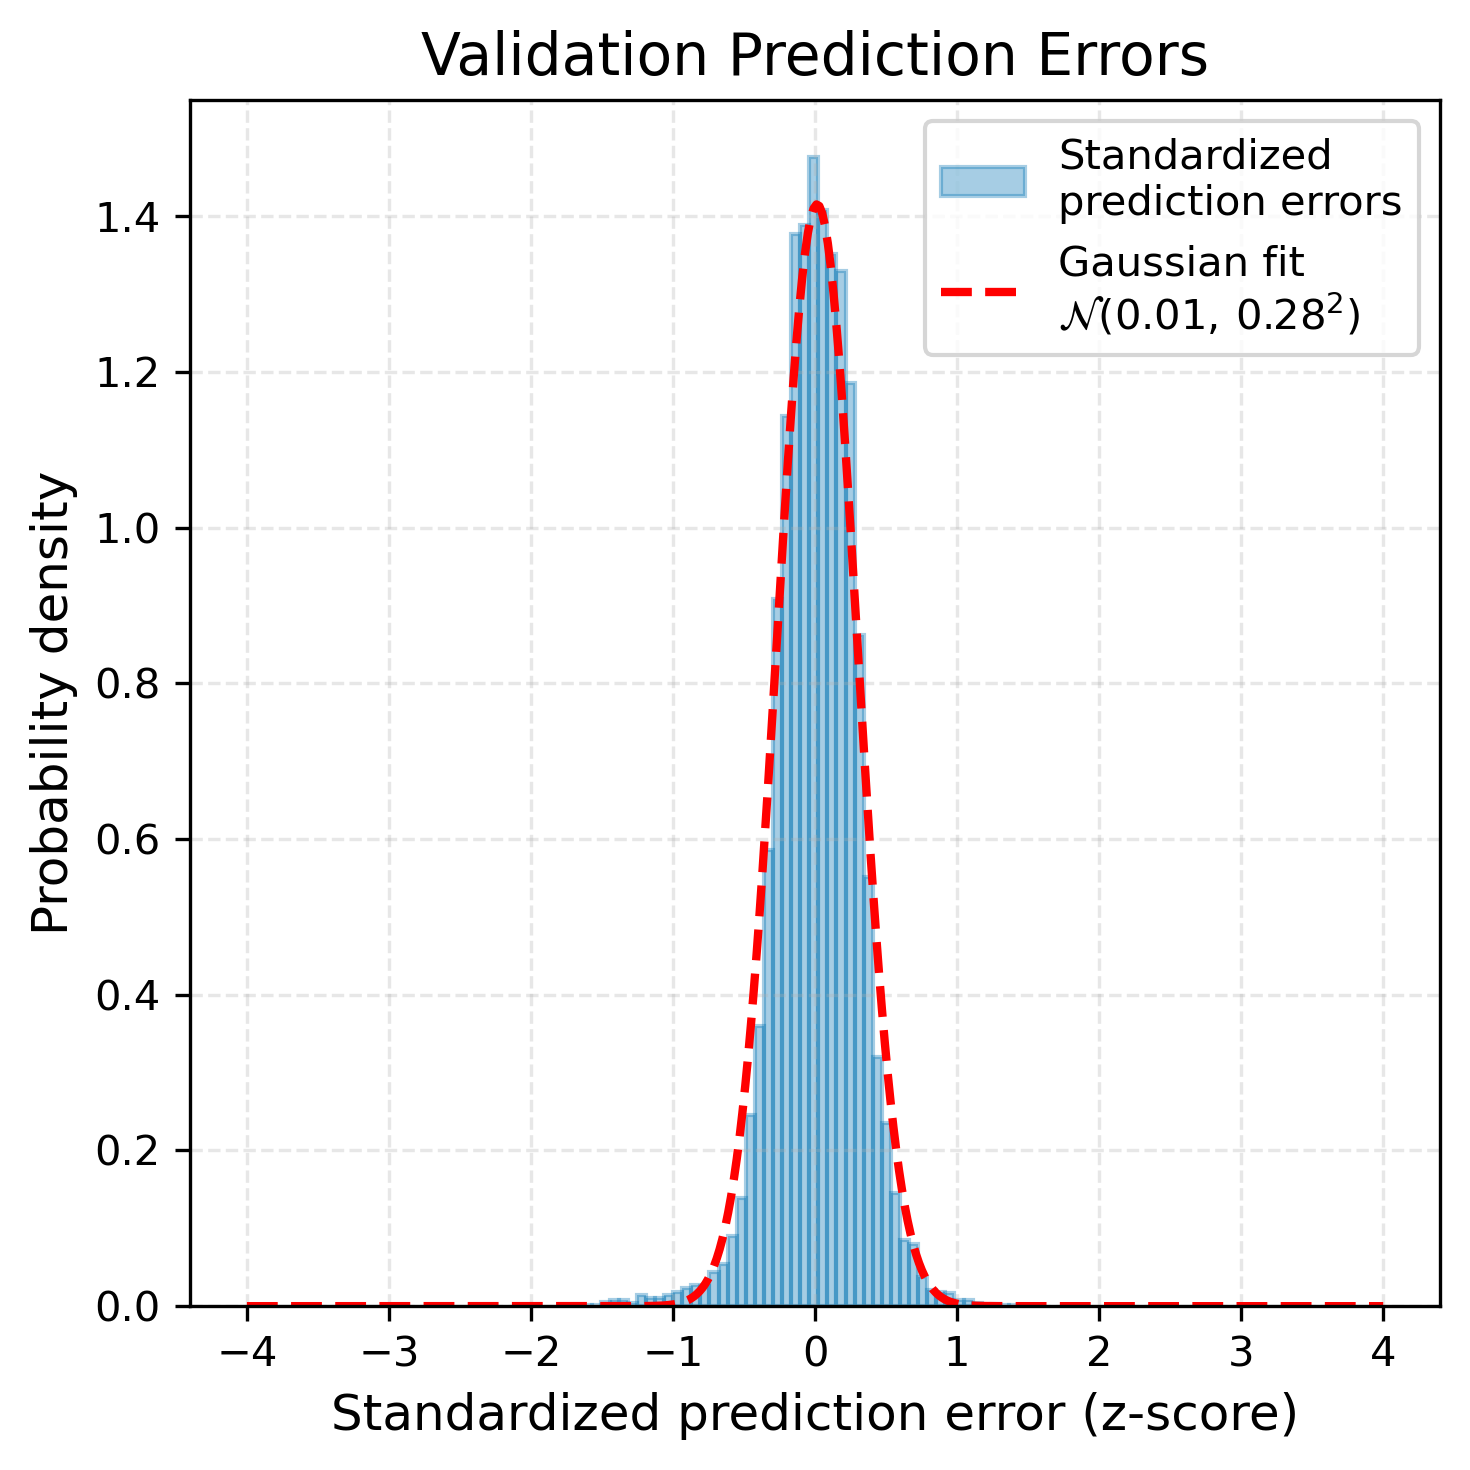

In [44]:
# Fit the bell curve with the data
import scipy.stats as stats

# # =====================================
# # Safety check: remove NaNs or infs
# # =====================================
# val_zscores = val_zscores[np.isfinite(val_zscores)]

# =====================================
# Fit Gaussian parameters (MLE)
# =====================================
mu_fit = np.mean(val_zscores)
sigma_fit = np.std(val_zscores, ddof=1)

print(f"Fitted Gaussian parameters:")
print(f"Mean (mu)      = {mu_fit:.4f}")
print(f"Std  (sigma)   = {sigma_fit:.4f}")

# =====================================
# Plot histogram of z-scores
# =====================================
plt.figure(figsize=(5, 5), dpi=300)

plt.hist(
    val_zscores,
    bins=50,
    density=True,           # <-- makes y-axis probability density
    alpha=0.35,
    color="#0072B2",
    edgecolor="#0072B2",
    label="Standardized\nprediction errors"
)

# =====================================
# Plot fitted Gaussian PDF
# =====================================
x = np.linspace(-4, 4, 400)
plt.plot(
    x,
    stats.norm.pdf(x, mu_fit, sigma_fit),
    "r--",
    linewidth=2,
    label=f"Gaussian fit\n$\mathcal{{N}}({mu_fit:.2f},\,{sigma_fit:.2f}^2)$"
)

# =====================================
# Labels and styling
# =====================================
plt.xlabel("Standardized prediction error (z-score)", fontsize=12)
plt.ylabel("Probability density", fontsize=12)
plt.title("Validation Prediction Errors", fontsize=14)
plt.legend(fontsize=10)
plt.grid(alpha=0.3, linestyle="--")
plt.tight_layout()

# =====================================
# Save figure
# =====================================
plt.savefig(f"validation_normal_error_hist_{record}.png", dpi=300)
plt.show()


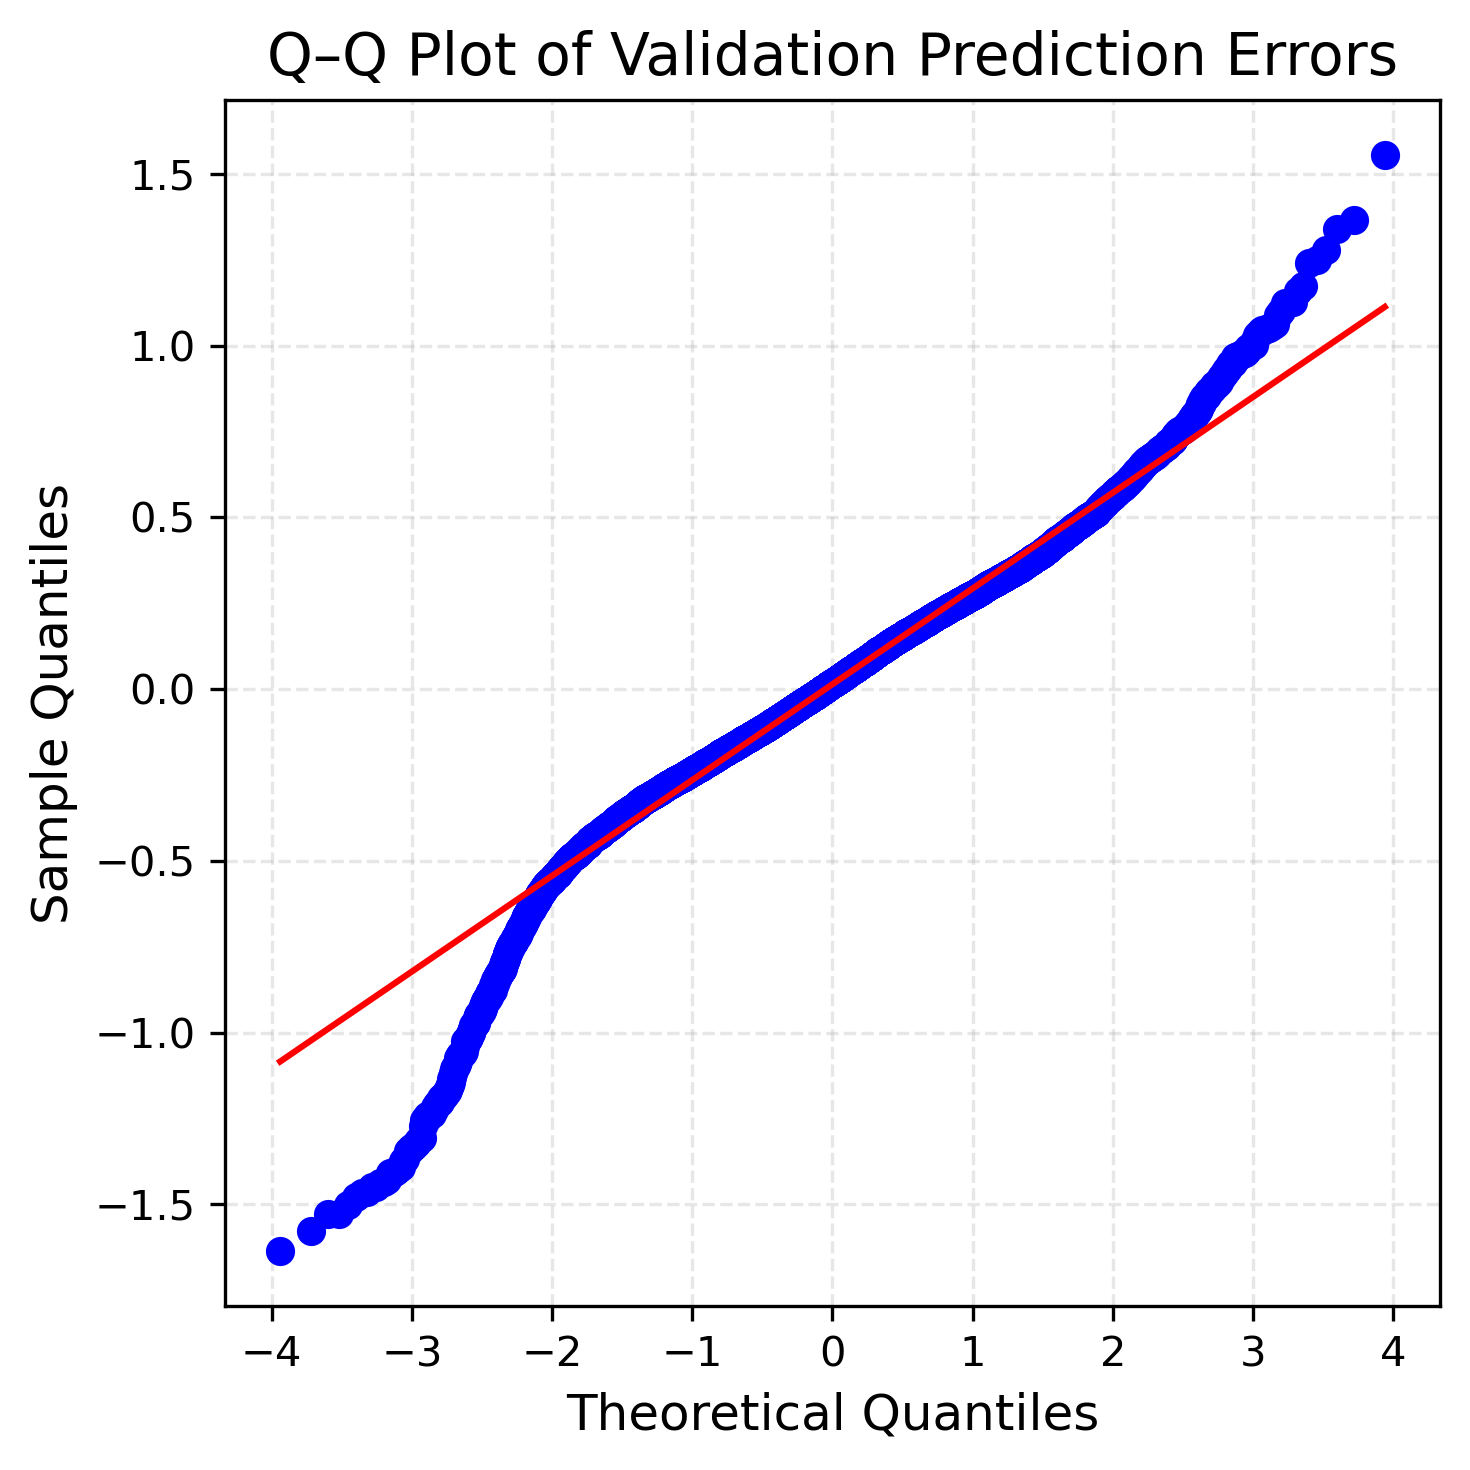

In [46]:
# Q-Q plot with respect to standard normal
plt.figure(figsize=(5, 5), dpi=300)

stats.probplot(val_zscores, dist="norm", plot=plt)

plt.title("Q–Q Plot of Validation Prediction Errors", fontsize=14)
plt.xlabel("Theoretical Quantiles", fontsize=12)
plt.ylabel("Sample Quantiles", fontsize=12)
plt.grid(alpha=0.3, linestyle="--")
plt.tight_layout()

plt.savefig(f"validation_normal_qqplot_{record}.png", dpi=300)
plt.show()
